# Terzaghi 1D Multilayer Verification Notebook

This notebook studies the 1D multilayer FEM consolidation model.

A closed-form analytical solution is not generally available for layered profiles, so the most useful verification route at this stage is reduction-style checking.

The current notebook focuses on:

1. reduction to the single-layer uniform-initial-condition case
2. reduction to the single-layer Boussinesq-initial-condition case using the arbitrary-`u0` analytical solver
3. a short record of the next verification checks still to add

This matches the current stage of the project: multilayer solving is implemented, while full multilayer verification is still in progress.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

%load_ext autoreload
%autoreload 2
import os
import sys
project_root = os.path.abspath(os.path.join('..'))
sys.path.insert(0, project_root)

from src.geotech_consolidation.models.terzaghi_1d.analytical import Get_terzaghi1d_Analytical
from src.geotech_consolidation.models.terzaghi_1d.u0_analytical import Get_terzaghi1d_Analytical_u0
from src.geotech_consolidation.models.terzaghi_1d_multi.fem import Get_terzaghi1dMultilayer_FEA

sns.set_theme(style="whitegrid")

load = 100.0
base = 10.0
num = 100
nodes = num + 1
depths = [5.0]
Cv = [2e-7]
Mv = [5e-4]
H = max(depths)
T = 365 * 24 * 60 * 60
time_steps = 1000
N_terms = 200

z = -np.linspace(0.0, H, nodes)
time_days = np.linspace(0.0, T / (60 * 60 * 24), time_steps)

## Reduction Test 1: Uniform Initial Condition

If the multilayer solver is given a single layer, it should recover the same behaviour as the single-layer solver. That is the first and most important reduction check.

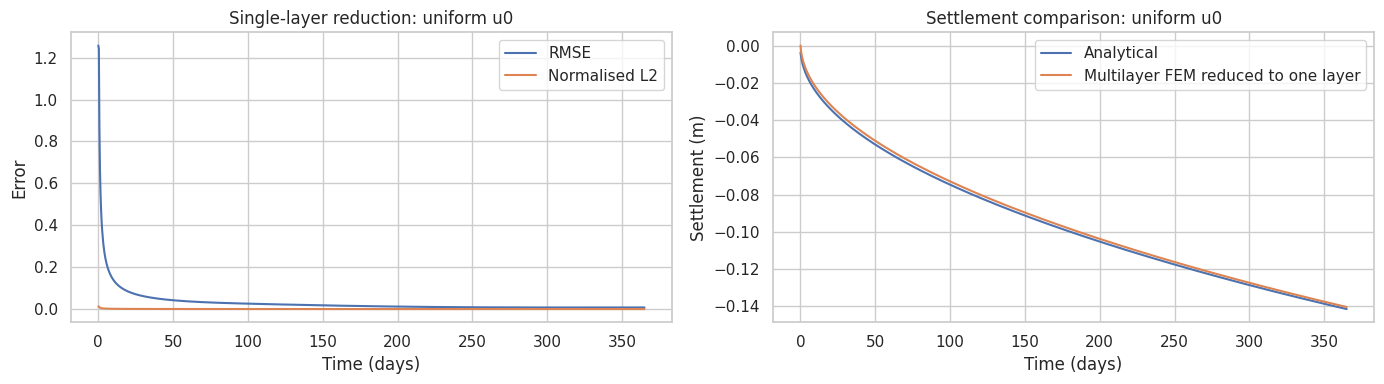

In [2]:
fem_settlement_u, fem_u_u, _ = Get_terzaghi1dMultilayer_FEA(
    depths, num, load, T, time_steps, Cv, Mv, Base=base, U0=True
)

analytical_c_u, analytical_u_u, depth_u, time_u = Get_terzaghi1d_Analytical(
    H, num, load, T, time_steps, Cv[0], N_terms
)

error_u = fem_u_u - analytical_u_u
rmse_u = np.sqrt((error_u**2).mean(axis=1))
num_u = (error_u**2).sum(axis=1)
den_u = (analytical_u_u**2).sum(axis=1)
norm_l2_u = np.sqrt(num_u / (den_u + 1e-12))

total_settlement = Mv[0] * load * H
analytical_settlement_u = analytical_c_u.mean(axis=1) * total_settlement

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(time_days, rmse_u, label="RMSE")
axes[0].plot(time_days, norm_l2_u, label="Normalised L2")
axes[0].set_xlabel("Time (days)")
axes[0].set_ylabel("Error")
axes[0].set_title("Single-layer reduction: uniform u0")
axes[0].legend()

axes[1].plot(time_days, -analytical_settlement_u, label="Analytical")
axes[1].plot(time_days, -fem_settlement_u, label="Multilayer FEM reduced to one layer")
axes[1].set_xlabel("Time (days)")
axes[1].set_ylabel("Settlement (m)")
axes[1].set_title("Settlement comparison: uniform u0")
axes[1].legend()

plt.tight_layout()
plt.show()

## Reduction Test 2: Boussinesq Initial Condition

For the Boussinesq-style initial condition, the most practical comparison is against the arbitrary-`u0` analytical solver using the FEM initial pore-pressure profile as the prescribed `u0(z)`.

This is not a closed-form multilayer solution. It is a reduction check that asks whether the one-layer multilayer FEM solution behaves consistently with the arbitrary-`u0` analytical model built from the same initial field.

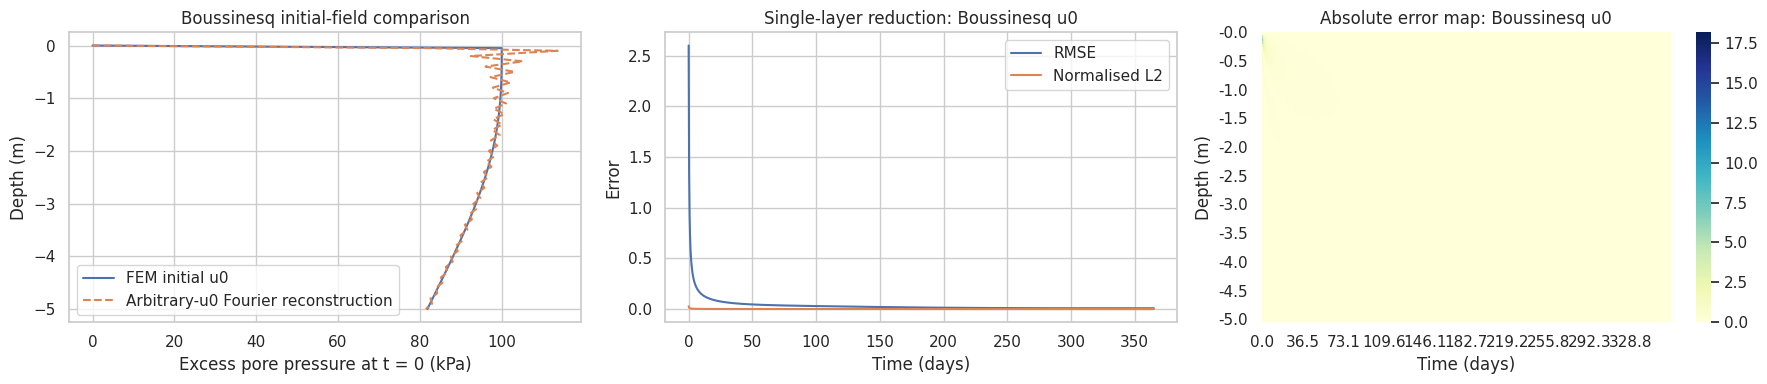

In [3]:
N_terms_b = max(3, nodes // 2)

fem_settlement_b, fem_u_b, _ = Get_terzaghi1dMultilayer_FEA(
    depths, num, load, T, time_steps, Cv, Mv, Base=base, U0=False
)

u0_b = fem_u_b[0, :]
analytical_u_b, depth_b, time_b = Get_terzaghi1d_Analytical_u0(
    u0_b, H, num, T, time_steps, Cv[0], N_terms_b
)

error_b = fem_u_b - analytical_u_b
rmse_b = np.sqrt((error_b**2).mean(axis=1))
num_b = (error_b**2).sum(axis=1)
den_b = (analytical_u_b**2).sum(axis=1)
norm_l2_b = np.sqrt(num_b / (den_b + 1e-12))

fig, axes = plt.subplots(1, 3, figsize=(18, 4))

axes[0].plot(u0_b, z, label="FEM initial u0")
axes[0].plot(analytical_u_b[0, :], z, "--", label="Arbitrary-u0 Fourier reconstruction")
axes[0].set_xlabel("Excess pore pressure at t = 0 (kPa)")
axes[0].set_ylabel("Depth (m)")
axes[0].set_title("Boussinesq initial-field comparison")
axes[0].legend()

axes[1].plot(time_b, rmse_b, label="RMSE")
axes[1].plot(time_b, norm_l2_b, label="Normalised L2")
axes[1].set_xlabel("Time (days)")
axes[1].set_ylabel("Error")
axes[1].set_title("Single-layer reduction: Boussinesq u0")
axes[1].legend()

kx = max(1, len(time_b) // 10)
ky = max(1, len(z) // 10)
sns.heatmap(
    np.abs(error_b).T,
    annot=False,
    cmap="YlGnBu",
    xticklabels=time_b,
    yticklabels=z,
    ax=axes[2],
)
axes[2].set_xticks(np.arange(0, len(time_b), kx) + 0.5)
axes[2].set_xticklabels([f"{time_b[i]:.1f}" for i in range(0, len(time_b), kx)], rotation=0)
axes[2].set_yticks(np.arange(0, len(z), ky) + 0.5)
axes[2].set_yticklabels([f"{z[i]:.1f}" for i in range(0, len(z), ky)], rotation=0)
axes[2].set_xlabel("Time (days)")
axes[2].set_ylabel("Depth (m)")
axes[2].set_title("Absolute error map: Boussinesq u0")

plt.tight_layout()
plt.show()

## Verification Checks Still To Add

The next multilayer verification checks to add are:

1. **uniform-property reduction across multiple layers**
   Use multiple depth intervals but keep `Cv` and `Mv` identical in every layer. The multilayer result should collapse back onto the single-layer result.

2. **interface continuity checks**
   Check that pore pressure remains continuous at each interface and that the expected change is in the gradient or flux response, not in a spurious jump in `u` itself.

3. **settlement partition by layer**
   Compare the contribution of each layer to total settlement against hand-calculation expectations for simple profiles.

4. **mesh and time-step sensitivity for layered cases**
   Repeat refinement studies with at least one strongly contrasting layered profile.

5. **manufactured-solution or source-term verification**
   This is the stronger formal PDE verification route, but it is a separate step from the current reduction tests.

## Short Note on Total Settlement and Quadrature

For the multilayer case, settlement is still based on a depth integral of strain:

`s(t) = integral_0^H Mv(z) [u0(z) - u(z, t)] dz`

The key difference is that `Mv(z)` is piecewise constant by layer. Numerically, the total settlement still depends on the chosen depth quadrature, for example:

- rectangle-rule style summation over nodal or cell values
- trapezoidal integration over the depth coordinate

That choice should be stated explicitly in the dissertation, especially once settlement partition by layer is discussed.